# Mini-proyecto de Computer Vision (OpenCV): *lectura didáctica* de una matrícula UK (amarilla) sin OCR

> **Objetivo didáctico**: construir un pipeline que combine varias técnicas clásicas de CV, **sin pretender ser perfecto**, para:
1. Cargar una imagen (local o URL) con la **parte trasera de un coche** y una **matrícula UK amarilla**.
2. **Normalizar** valores (0–1) y **redimensionar** la imagen.
3. Usar **K-Means** sobre píxeles para quedarnos con la región **amarilla** (matrícula + ruido).
4. **Binarizar** y aplicar **morfología** (erode/dilate) para limpiar.
5. Localizar la **caja de la matrícula** con **proyecciones** (sumas por fila/columna).
6. Segmentar cada **carácter** con la misma idea (proyección vertical).
7. Reconocer cada carácter por **comparación con plantillas** (*template matching*).
8. Devolver la predicción final.

---

## ⚠️ Aviso importante (ético y práctico)
- Usa imágenes **propias** o con derechos adecuados (o datasets educativos).
- Este notebook es **para aprender** técnicas, no para desplegar un sistema robusto en producción.

---

## Requisitos
- `opencv-python`
- `numpy`
- `matplotlib`
- (opcional) `requests` para cargar desde URL

In [327]:
# Si estás en Colab / entorno limpio:
# !pip -q install opencv-python matplotlib requests

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Opcional para URLs
import requests
from io import BytesIO

In [328]:
# --- Configuración de entrada ---
USE_URL = True

# URL por defecto (Wikimedia Commons). Si falla, pon USE_URL=False y usa ruta local.
IMAGE_URL = "https://cdn.warrantywise.co.uk/wp-content/uploads/2020/09/03115906/The-New-70-Plate-Registration-Has-Launched-Cover-Photo.jpg.webp"
LOCAL_PATH = None

In [329]:
def load_image_bgr(use_url=True, image_url=None, local_path=None):
    """Carga una imagen en BGR (formato OpenCV), desde URL o disco."""
    if use_url:
        if not image_url:
            raise ValueError("Falta IMAGE_URL")
        r = requests.get(image_url, timeout=30)
        r.raise_for_status()
        img_arr = np.frombuffer(r.content, dtype=np.uint8)
        img = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
        if img is None:
            raise ValueError("No se pudo decodificar la imagen desde URL.")
        return img
    else:
        if not local_path:
            raise ValueError("Falta LOCAL_PATH")
        img = cv2.imread(local_path, cv2.IMREAD_COLOR)
        if img is None:
            raise ValueError(f"No se pudo leer la imagen: {local_path}")
        return img

img_bgr = load_image_bgr(USE_URL, IMAGE_URL, LOCAL_PATH)

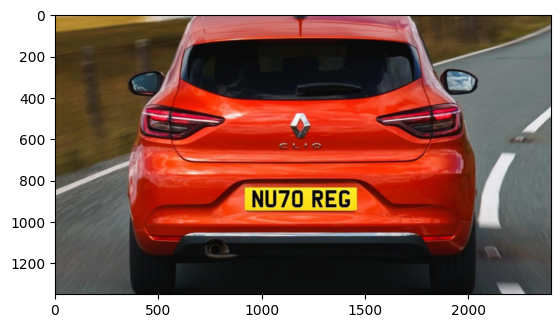

In [330]:
plt.imshow(img_bgr[:, :, [2,1,0]])

## K-Means

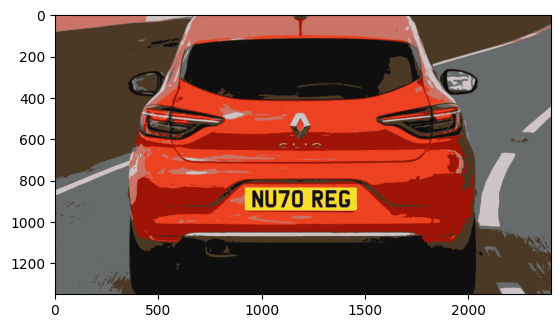

In [ ]:
img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) # Change to RGB for matplotlib

pixel_vals = img_bgr.reshape((-1,3)) # Reshape to a list of pixels (N, 3)

pixel_vals = np.float32(pixel_vals) # Convert to float32 for kmeans

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)

k = 8

retval, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)

segmented_data = centers[labels.flatten()]

segmented_image = segmented_data.reshape((img_bgr.shape[0], img_bgr.shape[1], img_bgr.shape[2]))

plt.imshow(segmented_image)

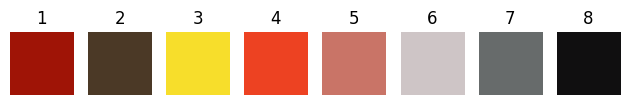

In [ ]:
labels = labels.flatten() # Transform into 1D array

for idx, color in enumerate(centers):
    
    plt.subplot(1, k, idx+1)
    plt.axis('off')
    plt.imshow([[color / 255]])
    plt.title(f'{idx+1}')

plt.tight_layout()
plt.show()

In [334]:
for i, cluster in enumerate(centers):
    print(f"Cluster {i+1}: RGB = {cluster}")

Cluster 1: RGB = [159  20   6]
Cluster 2: RGB = [75 57 38]
Cluster 3: RGB = [247 222  43]
Cluster 4: RGB = [237  66  34]
Cluster 5: RGB = [201 116 103]
Cluster 6: RGB = [206 197 198]
Cluster 7: RGB = [103 107 107]
Cluster 8: RGB = [16 15 16]


In [344]:
yellow = [250, 250, 20]

dist = np.sum((centers - yellow) ** 2, axis=1) # Euclidean distance squared

yellow_cluster_idx = np.argmin(dist) # Index of the closest cluster (yellow)

print(f"Nearest Cluster similar to Yellow is the {yellow_cluster_idx + 1} with RGB = {centers[yellow_cluster_idx]}")

Nearest Cluster similar to Yellow is the 3 with RGB = [247 222  43]


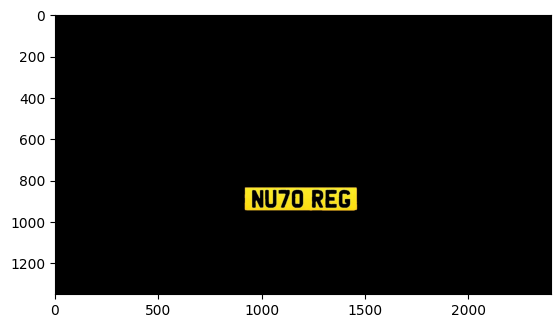

In [345]:
mask = (labels == yellow_cluster_idx).astype(np.uint8) * 255 # Binary mask for the yellow cluster
mask = mask.reshape(img_bgr.shape[:2]) # Reshape to original image dimensions (height, width)

res = cv2.bitwise_and(img_bgr, img_bgr, mask=mask) # Apply mask to original image

plt.imshow(res)

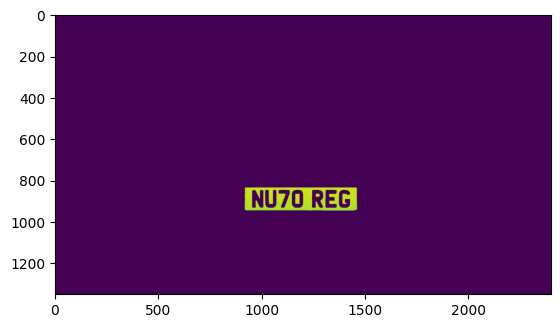

In [346]:
res = cv2.cvtColor(res, cv2.COLOR_RGB2GRAY) # Convert to grayscale for better visualization of the masked area

plt.imshow(res)

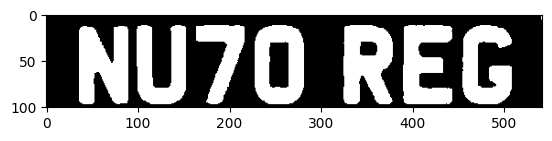

In [ ]:
line, thresh = cv2.threshold(res, 0, 255, cv2.THRESH_BINARY) # Apply binary thresholding to get a binary image of the license plate area

m = (thresh > 0).astype(int)

sumas_filas = np.sum(m, axis=1) # Sum horizontally to get the density of white pixels in each row
umbral_y = np.max(sumas_filas) * 0.20 # Ignore rows with less than 20% of the maximum white pixel count
filas_validas = np.where(sumas_filas > umbral_y)[0]

# Keep the first and last valid rows with white pixels
y0, y1 = filas_validas[0], filas_validas[-1] 

m_recortada_horizontal = m[y0:y1, :] # Crop the binary mask to the valid rows

sumas_columnas = np.sum(m_recortada_horizontal, axis=0) # Vertically sum
umbral_x = np.max(sumas_columnas) * 0.20
cols_validas = np.where(sumas_columnas > umbral_x)[0]

# Keep the first and last valid columns with white pixels
x0, x1 = cols_validas[0], cols_validas[-1]

matricula_recortada = thresh[y0:y1 - 10, x0:x1] # Crop the original thresholded image to the valid rows and columns
matricula_recortada = 255 - matricula_recortada # Invert colors

plt.imshow(matricula_recortada, cmap='gray')

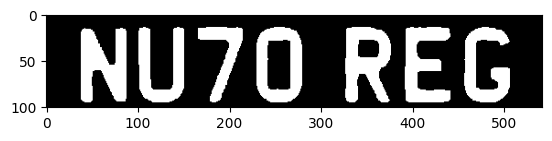

In [ ]:
kernel = np.ones((5, 5), np.uint8) # Define a 5x5 kernel for morphological operations

dilation = cv2.erode(matricula_recortada, kernel, iterations=1) # Erode to remove small noise and separate characters

plt.imshow(dilation, cmap='gray') 

Text(0.5, 1.0, 'Histograma vertical de la matrícula')

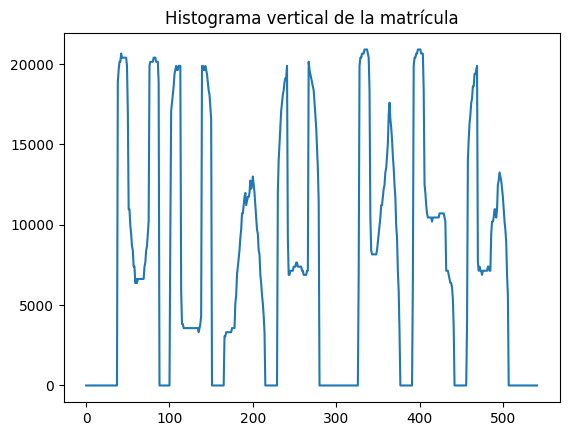

In [ ]:
vertical_sum = np.sum(dilation, axis=0) # Vertically sum the pixel values to get a histogram of character density across the width of the license plate

plt.plot(vertical_sum)

plt.title("Histograma vertical de la matrícula")

In [ ]:
character_positions = [] # List to store the start and end positions of each character
char_arr = [] # List to store the extracted character images
start = None # Flag

for i, sum_val in enumerate(vertical_sum): # Iterate through the vertical histogram to find character boundaries
    if sum_val > 0 and start is None: # Start of a character
        start = i
        
    elif sum_val == 0 and start is not None: # End of a character
        character_positions.append((start, i))
        start = None

for i, (start, end) in enumerate(character_positions): # Extract and save each character based on the identified positions
    char = dilation[:, start:end]
    cv2.imwrite(f'char_{i}.png', 255 - char)
    char_arr.append(char.copy())


# TEMPLATES

In [342]:
TEMPLATE_H = 45
TEMPLATE_W = 33

ALPHABET = list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")

def make_template(char, w=TEMPLATE_W, h=TEMPLATE_H):
    img = np.zeros((h, w), dtype=np.uint8)
    # Fuente Hershey; probamos una combinación que suele verse "placa"
    font = cv2.FONT_HERSHEY_SIMPLEX  
    scale = 1.8
    thickness = 5

    # Centramos el texto
    (tw, th), baseline = cv2.getTextSize(char, font, scale, thickness)
    x = 2+(w - tw) // 2
    y = -2 + (h + th) // 2
    cv2.putText(img, char, (x, y), font, scale, 255, thickness, cv2.LINE_AA)

    # Opcional: pequeña dilatación para engordar un pelín
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    img = cv2.dilate(img, k, iterations=1)

    return img

templates = {ch: make_template(ch) for ch in ALPHABET}


In [350]:
prediction = ""

# Take each character image and compare it against all templates to find the best match
for i, char_img in enumerate(char_arr):
    
    # Resize the character image to match the template size (33x45)
    char_resized = cv2.resize(char_img, (TEMPLATE_W, TEMPLATE_H))
    char_resized = char_resized.astype(np.uint8)
    
    best_letter = "?"
    best_score = -1
    
    # Compare with each template (A-Z, 0-9) to find the best match
    for letra_plantilla, img_plantilla in templates.items():
        
        resultado = cv2.matchTemplate(char_resized, img_plantilla, cv2.TM_CCOEFF_NORMED)
        
        # Returns the best match value (max_val) which is a similarity score between -1.0 and 1.0
        _, max_val, _, _ = cv2.minMaxLoc(resultado)
        
        # If this letter matches better than previous ones, save it as the best match
        if max_val > best_score:
            best_score = max_val
            best_letter = letra_plantilla
            
    # Save the best matching letter for this character and print the confidence
    prediction += best_letter
    print(f"Letter {i}: Seems similar to the '{best_letter}' (Confidence: {round(best_score*100, 1)}%)")

print(f"\nFinal prediction: {prediction}")


Letter 0: Seems similar to the 'N' (Confidence: 72.3%)
Letter 1: Seems similar to the 'U' (Confidence: 81.2%)
Letter 2: Seems similar to the '7' (Confidence: 41.6%)
Letter 3: Seems similar to the '0' (Confidence: 62.4%)
Letter 4: Seems similar to the 'R' (Confidence: 39.4%)
Letter 5: Seems similar to the 'C' (Confidence: 37.4%)
Letter 6: Seems similar to the 'G' (Confidence: 55.0%)

Final prediction: NU70RCG
